# Retail Demand Forecasting

Прогноз спроса на товары в магазинах на 30 дней вперёд.

После первого дня модель использует свои прошлые прогнозы для расчёта новых признаков.

## 1. Постановка задачи

Нужно предсказать `target_quantity` для каждой пары `item_id × store_id`.

Основная метрика — WAPE. Также считаю MAE и RMSE. Случайное разделение не использую, чтобы данные из будущего не попали в обучение.

## 2. Загрузка данных

Использую готовые таблицы train, valid и test. Их периоды не пересекаются.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from catboost import CatBoostRegressor, Pool
from IPython.display import display
from lightgbm import LGBMRegressor
from matplotlib.colors import LinearSegmentedColormap
from sklearn.metrics import mean_absolute_error, mean_squared_error

PROJECT_DIR = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_DIR = PROJECT_DIR / 'data'
MODELS_DIR = PROJECT_DIR / 'models'

PURPLE = '#6A0DAD'
ORANGE = '#FF8C00'
PURPLE_ORANGE = LinearSegmentedColormap.from_list('purple_orange', [PURPLE, ORANGE])

train = pd.read_parquet(DATA_DIR / 'train.parquet')
valid = pd.read_parquet(DATA_DIR / 'valid.parquet')
test = pd.read_parquet(DATA_DIR / 'test.parquet')

c:\Users\gasre\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 3. Разделение по времени

Valid и test содержат по 30 дней. На valid выбираю модель, а на test оцениваю итоговый результат.

In [2]:
overview = []

for name, frame in {'train': train, 'valid': valid, 'test': test}.items():
    overview.append({
        'table': name,
        'rows': len(frame),
        'columns': frame.shape[1],
        'date_min': frame['date'].min(),
        'date_max': frame['date'].max(),
        'duplicates': frame.duplicated().sum(),
    })

overview = pd.DataFrame(overview)
display(overview)

assert train['date'].max() < valid['date'].min()
assert valid['date'].max() < test['date'].min()
assert valid['date'].nunique() == 30
assert test['date'].nunique() == 30

,table,rows,columns,date_min,date_max,duplicates
0,train,265035,44,2023-03-27,2024-07-28,0
1,valid,16710,44,2024-07-29,2024-08-27,0
2,test,16710,44,2024-08-28,2024-09-26,0


## 4. Проверка данных

Проверяю целевой признак, пропуски и отрицательные продажи. Пропуски в лагах и скользящих средних в начале ряда ожидаемы.

Цены, промо и онлайн-продажи не использую: неизвестно, будут ли они доступны на все 30 будущих дней.

In [3]:
missing = pd.DataFrame({
    'missing_count': train.isna().sum(),
    'missing_share': train.isna().mean(),
}).sort_values('missing_share', ascending=False)

display(train['target_quantity'].describe().to_frame())
display(missing[missing['missing_count'] > 0])
print(f"Доля нулевых продаж: {(train['target_quantity'] == 0).mean():.2%}")

negative_sales = train.loc[
    train['target_quantity'] < 0,
    ['date', 'item_id', 'store_id', 'target_quantity', 'class_name', 'item_type'],
]
display(negative_sales)

,target_quantity
count,265035.000000
mean,30.721353
std,86.953633
min,-3.000000
25%,4.000000
50%,14.000000
75%,31.000000
max,4447.000000


,missing_count,missing_share
markdown_price,264710,0.998774
markdown_normal_price,264710,0.998774
markdown_depth,264710,0.998774
promo_type_code,234080,0.883204
fatness,229323,0.865256
promo_depth,229259,0.865014
promo_price,229259,0.865014
price_before_promo,229259,0.865014
promo_day,229259,0.865014
weight_volume,80785,0.304809


Доля нулевых продаж: 14.21%


,date,item_id,store_id,target_quantity,class_name,item_type
117871,2023-10-21,d41f4b61b0fe,1,-3.000,ЯЙЦО,Куриное
125946,2024-06-13,e1555c63e06c,1,-0.030,НЕКОРНЕПЛОДЫ,Томаты
181779,2023-09-24,52738439ad17,2,-1.972,МЯСО ОХЛАЖДЕННОЕ СВИНИНА,Свинина
227373,2023-04-17,b49919095c52,2,-3.000,СУШИ ШТУЧНЫЕ,Соусы


In [4]:
train = train.loc[train['target_quantity'] >= 0].copy()
valid = valid.loc[valid['target_quantity'] >= 0].copy()
test = test.loc[test['target_quantity'] >= 0].copy()

assert (train['target_quantity'] < 0).sum() == 0
assert (valid['target_quantity'] < 0).sum() == 0
assert (test['target_quantity'] < 0).sum() == 0

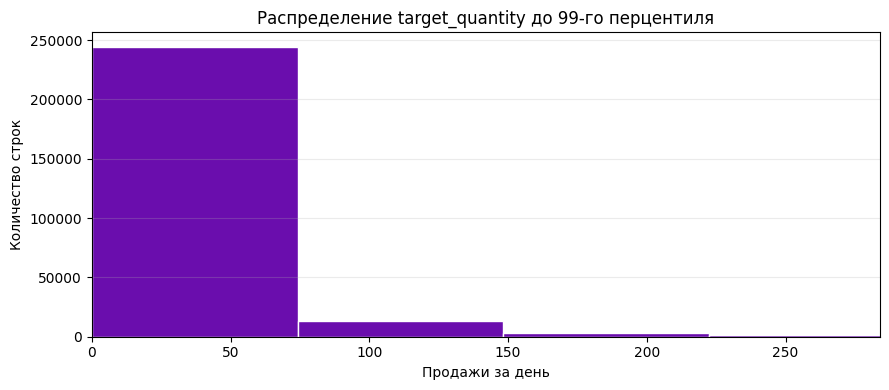

In [5]:
plt.figure(figsize=(9, 4))
plt.hist(train['target_quantity'], bins=60, color=PURPLE, edgecolor='white')
plt.xlim(0, train['target_quantity'].quantile(0.99))
plt.xlabel('Продажи за день')
plt.ylabel('Количество строк')
plt.title('Распределение target_quantity до 99-го перцентиля')
plt.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

### Вывод

В продажах много нулей и есть редкие крупные значения. Четыре отрицательные строки похожи на возвраты, поэтому удаляю их.

## 5. Подготовка признаков

Использую календарь, прошлые продажи, скользящие средние и характеристики товара и магазина.

In [6]:
id_features = ['item_id', 'store_id']
calendar_features = ['year', 'month', 'day', 'dayofweek', 'weekofyear', 'is_weekend']
lag_features = ['target_lag_1', 'target_lag_7', 'target_lag_14', 'target_lag_28']
rolling_features = ['target_rolling_mean_7', 'target_rolling_mean_14', 'target_rolling_mean_28']
static_features = [
    'dept_name', 'class_name', 'subclass_name', 'item_type',
    'weight_volume', 'weight_netto', 'fatness',
    'division', 'format', 'city', 'area',
]

e1_features = id_features + calendar_features + lag_features
e2_features = e1_features + rolling_features
e3_features = e2_features + static_features

cat_features = [
    'item_id', 'store_id', 'dept_name', 'class_name',
    'subclass_name', 'item_type', 'division', 'format', 'city',
]

catboost_train = train.copy()
catboost_valid = valid.copy()
catboost_train[cat_features] = catboost_train[cat_features].astype(str)
catboost_valid[cat_features] = catboost_valid[cat_features].astype(str)

## 6. Простой базовый прогноз

### Гипотеза

Спрос может повторяться по неделям. Поэтому первый прогноз равен продажам семь дней назад.

In [7]:
y_valid = valid['target_quantity']
lag7_oracle_prediction = valid['target_lag_7']
lag7_mask = lag7_oracle_prediction.notna()

lag7_oracle_mae = mean_absolute_error(y_valid[lag7_mask], lag7_oracle_prediction[lag7_mask])
lag7_oracle_rmse = mean_squared_error(y_valid[lag7_mask], lag7_oracle_prediction[lag7_mask]) ** 0.5
lag7_oracle_wape = np.abs(y_valid[lag7_mask] - lag7_oracle_prediction[lag7_mask]).sum() / np.abs(y_valid[lag7_mask]).sum()

## 7. Рекурсивный прогноз

Обычная оценка на valid будет нечестной: часть лагов рассчитана по будущим продажам.

Поэтому прогноз каждого дня добавляется в историю и используется для следующего дня.

In [8]:
def recursive_forecast(model, history_data, future_data, model_features):
    history = history_data.pivot(index='date', columns=['item_id', 'store_id'], values='target_quantity')
    lag7_history = history.copy()
    result = []

    for forecast_date in sorted(future_data['date'].unique()):
        day = future_data.loc[future_data['date'] == forecast_date].copy()
        pairs = pd.MultiIndex.from_frame(day[['item_id', 'store_id']])

        day['target_lag_1'] = history.reindex(index=[forecast_date - pd.Timedelta(days=1)], columns=pairs).iloc[0].to_numpy()
        day['target_lag_7'] = history.reindex(index=[forecast_date - pd.Timedelta(days=7)], columns=pairs).iloc[0].to_numpy()
        day['target_lag_14'] = history.reindex(index=[forecast_date - pd.Timedelta(days=14)], columns=pairs).iloc[0].to_numpy()
        day['target_lag_28'] = history.reindex(index=[forecast_date - pd.Timedelta(days=28)], columns=pairs).iloc[0].to_numpy()

        past = history.loc[history.index < forecast_date].reindex(columns=pairs)
        day['target_rolling_mean_7'] = past.tail(7).mean().to_numpy()
        day['target_rolling_mean_14'] = past.tail(14).mean().to_numpy()
        day['target_rolling_mean_28'] = past.tail(28).mean().to_numpy()

        day['prediction'] = np.clip(model.predict(day[model_features]), 0, None)
        day['lag7_recursive'] = lag7_history.reindex(index=[forecast_date - pd.Timedelta(days=7)], columns=pairs).iloc[0].to_numpy()

        history = pd.concat([history, pd.DataFrame([day['prediction'].to_numpy()], index=[forecast_date], columns=pairs)])
        lag7_history = pd.concat([lag7_history, pd.DataFrame([day['lag7_recursive'].to_numpy()], index=[forecast_date], columns=pairs)])
        result.append(day)

    return pd.concat(result, ignore_index=True)

## 8. Первая модель CatBoost

Сначала обучаю CatBoost с базовыми параметрами. Сравниваю обычную и рекурсивную оценку.

In [9]:
X_train = catboost_train[e3_features]
y_train = catboost_train['target_quantity']

model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.1,
    depth=6,
    loss_function='MAE',
    random_seed=42,
    verbose=False,
)

model.fit(X_train, y_train, cat_features=cat_features)

catboost_oracle_prediction = np.clip(model.predict(catboost_valid[e3_features]), 0, None)
catboost_oracle_mae = mean_absolute_error(y_valid, catboost_oracle_prediction)
catboost_oracle_rmse = mean_squared_error(y_valid, catboost_oracle_prediction) ** 0.5
catboost_oracle_wape = np.abs(y_valid - catboost_oracle_prediction).sum() / np.abs(y_valid).sum()

recursive_valid = recursive_forecast(model, catboost_train, catboost_valid, e3_features)
y_recursive = recursive_valid['target_quantity']
catboost_recursive_prediction = recursive_valid['prediction']
lag7_recursive_prediction = recursive_valid['lag7_recursive']
lag7_recursive_mask = lag7_recursive_prediction.notna()

catboost_recursive_mae = mean_absolute_error(y_recursive, catboost_recursive_prediction)
catboost_recursive_rmse = mean_squared_error(y_recursive, catboost_recursive_prediction) ** 0.5
catboost_recursive_wape = np.abs(y_recursive - catboost_recursive_prediction).sum() / np.abs(y_recursive).sum()

lag7_recursive_mae = mean_absolute_error(y_recursive[lag7_recursive_mask], lag7_recursive_prediction[lag7_recursive_mask])
lag7_recursive_rmse = mean_squared_error(y_recursive[lag7_recursive_mask], lag7_recursive_prediction[lag7_recursive_mask]) ** 0.5
lag7_recursive_wape = np.abs(y_recursive[lag7_recursive_mask] - lag7_recursive_prediction[lag7_recursive_mask]).sum() / np.abs(y_recursive[lag7_recursive_mask]).sum()

oracle_recursive = pd.DataFrame({
    'model': ['Lag7 oracle', 'CatBoost oracle', 'Lag7 recursive', 'CatBoost recursive'],
    'MAE': [lag7_oracle_mae, catboost_oracle_mae, lag7_recursive_mae, catboost_recursive_mae],
    'RMSE': [lag7_oracle_rmse, catboost_oracle_rmse, lag7_recursive_rmse, catboost_recursive_rmse],
    'WAPE': [lag7_oracle_wape, catboost_oracle_wape, lag7_recursive_wape, catboost_recursive_wape],
})

oracle_recursive

,model,MAE,RMSE,WAPE
0,Lag7 oracle,8.929505,20.251237,0.329451
1,CatBoost oracle,6.562632,15.801721,0.242126
2,Lag7 recursive,9.976121,21.364644,0.368066
3,CatBoost recursive,8.451274,19.357873,0.311807


### Вывод

Обычная оценка лучше, потому что использует реальные продажи внутри valid. Рекурсивная оценка ближе к реальной работе модели.

## 9. Проверка групп признаков

По очереди добавляю признаки и сравниваю WAPE:

- E0 — продажи семь дней назад;
- E1 — лаги и календарь;
- E2 — добавлены скользящие средние;
- E3 — добавлены признаки товара и магазина.

In [10]:
def run_experiment(name, experiment_features):
    experiment_cat_features = [column for column in cat_features if column in experiment_features]
    experiment_model = CatBoostRegressor(iterations=500, learning_rate=0.1, depth=6, loss_function='MAE', random_seed=42, verbose=False)
    experiment_model.fit(catboost_train[experiment_features], y_train, cat_features=experiment_cat_features)

    experiment_valid = recursive_forecast(experiment_model, catboost_train, catboost_valid, experiment_features)
    y_true = experiment_valid['target_quantity']
    y_pred = experiment_valid['prediction']

    return {
        'experiment': name,
        'features': len(experiment_features),
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': mean_squared_error(y_true, y_pred) ** 0.5,
        'WAPE': np.abs(y_true - y_pred).sum() / np.abs(y_true).sum(),
    }


e0_result = {'experiment': 'E0 Seasonal Naive', 'features': 1, 'MAE': lag7_recursive_mae, 'RMSE': lag7_recursive_rmse, 'WAPE': lag7_recursive_wape}
e1_result = run_experiment('E1 Lags + calendar', e1_features)
e2_result = run_experiment('E2 + rolling', e2_features)
e3_result = {'experiment': 'E3 + product/store', 'features': len(e3_features), 'MAE': catboost_recursive_mae, 'RMSE': catboost_recursive_rmse, 'WAPE': catboost_recursive_wape}

ablation_results = pd.DataFrame([e0_result, e1_result, e2_result, e3_result])
ablation_results

,experiment,features,MAE,RMSE,WAPE
0,E0 Seasonal Naive,1,9.976121,21.364644,0.368066
1,E1 Lags + calendar,12,8.792814,19.727344,0.324408
2,E2 + rolling,15,8.807001,20.961449,0.324932
3,E3 + product/store,26,8.451274,19.357873,0.311807


### Вывод

Скользящие средние отдельно не помогли. Признаки товара и магазина улучшили результат, поэтому выбираю E3.

## 10. Сравнение моделей

Сравниваю CatBoost и LightGBM на одинаковых данных и признаках.

In [11]:
lgbm_train = train.copy()
lgbm_valid = valid.copy()

for column in cat_features:
    lgbm_train[column] = lgbm_train[column].astype('category')
    categories = lgbm_train[column].cat.categories
    lgbm_valid[column] = pd.Categorical(lgbm_valid[column], categories=categories)

model_lgbm = LGBMRegressor(n_estimators=500, learning_rate=0.1, max_depth=6, random_state=42, verbosity=-1)
model_lgbm.fit(lgbm_train[e3_features], lgbm_train['target_quantity'], categorical_feature=cat_features)

lgbm_recursive = recursive_forecast(model_lgbm, lgbm_train, lgbm_valid, e3_features)
y_lgbm = lgbm_recursive['target_quantity']
pred_lgbm = lgbm_recursive['prediction']

lgbm_recursive_mae = mean_absolute_error(y_lgbm, pred_lgbm)
lgbm_recursive_rmse = mean_squared_error(y_lgbm, pred_lgbm) ** 0.5
lgbm_recursive_wape = np.abs(y_lgbm - pred_lgbm).sum() / np.abs(y_lgbm).sum()

In [12]:
model_comparison = pd.DataFrame({
    'Model': ['Seasonal Naive', 'CatBoost E3', 'LightGBM'],
    'MAE': [lag7_recursive_mae, catboost_recursive_mae, lgbm_recursive_mae],
    'RMSE': [lag7_recursive_rmse, catboost_recursive_rmse, lgbm_recursive_rmse],
    'WAPE': [lag7_recursive_wape, catboost_recursive_wape, lgbm_recursive_wape],
})

model_comparison

,Model,MAE,RMSE,WAPE
0,Seasonal Naive,9.976121,21.364644,0.368066
1,CatBoost E3,8.451274,19.357873,0.311807
2,LightGBM,10.543399,25.752901,0.388995


### Вывод

CatBoost показал лучший WAPE. Поэтому дальше настраиваю только его.

## 11. Подбор параметров

Проверяю восемь наборов параметров. Полный перебор потребовал бы слишком много времени.

In [13]:
tuning_configs = [
    {'name': 'T1', 'depth': 4, 'learning_rate': 0.10, 'l2_leaf_reg': 3, 'iterations': 500},
    {'name': 'T2', 'depth': 6, 'learning_rate': 0.10, 'l2_leaf_reg': 3, 'iterations': 500},
    {'name': 'T3', 'depth': 8, 'learning_rate': 0.10, 'l2_leaf_reg': 5, 'iterations': 500},
    {'name': 'T4', 'depth': 4, 'learning_rate': 0.05, 'l2_leaf_reg': 3, 'iterations': 1000},
    {'name': 'T5', 'depth': 6, 'learning_rate': 0.05, 'l2_leaf_reg': 5, 'iterations': 1000},
    {'name': 'T6', 'depth': 8, 'learning_rate': 0.05, 'l2_leaf_reg': 10, 'iterations': 1000},
    {'name': 'T7', 'depth': 6, 'learning_rate': 0.03, 'l2_leaf_reg': 5, 'iterations': 1500},
    {'name': 'T8', 'depth': 8, 'learning_rate': 0.03, 'l2_leaf_reg': 10, 'iterations': 1500},
]

tuning_results = []

for config in tuning_configs:
    tuned_model = CatBoostRegressor(**{key: value for key, value in config.items() if key != 'name'}, loss_function='MAE', random_seed=42, verbose=False)
    tuned_model.fit(catboost_train[e3_features], y_train, cat_features=cat_features)
    tuned_valid = recursive_forecast(tuned_model, catboost_train, catboost_valid, e3_features)
    tuned_y = tuned_valid['target_quantity']
    tuned_pred = tuned_valid['prediction']

    tuning_results.append({
        **config,
        'MAE': mean_absolute_error(tuned_y, tuned_pred),
        'RMSE': mean_squared_error(tuned_y, tuned_pred) ** 0.5,
        'WAPE': np.abs(tuned_y - tuned_pred).sum() / np.abs(tuned_y).sum(),
    })

tuning_results = pd.DataFrame(tuning_results).sort_values('WAPE').reset_index(drop=True)
tuning_results

,name,depth,learning_rate,l2_leaf_reg,iterations,MAE,RMSE,WAPE
0,T3,8,0.10,5,500,8.169231,18.432930,0.301401
1,T8,8,0.03,10,1500,8.185959,18.722126,0.302018
2,T6,8,0.05,10,1000,8.264531,19.697940,0.304917
3,T7,6,0.03,5,1500,8.438918,19.518821,0.311351
4,T2,6,0.10,3,500,8.451274,19.357873,0.311807
5,T5,6,0.05,5,1000,8.492986,20.659131,0.313346
6,T4,4,0.05,3,1000,8.915482,21.515605,0.328934
7,T1,4,0.10,3,500,9.328461,24.762223,0.344171


### Вывод

Лучший вариант — T6: `depth=8`, `learning_rate=0.05`, `l2_leaf_reg=10`, `iterations=1000`.

После этого параметры больше не меняю.

## 12. Итоговая модель

Объединяю train и valid. Для первого дня test использую всю известную историю, дальше — прошлые прогнозы модели.

In [14]:
best_params = {
    'iterations': 1000,
    'learning_rate': 0.05,
    'depth': 8,
    'l2_leaf_reg': 10,
    'loss_function': 'MAE',
    'random_seed': 42,
    'verbose': False,
}

train_final = pd.concat([catboost_train, catboost_valid], ignore_index=True)
train_final = train_final.sort_values(['item_id', 'store_id', 'date']).reset_index(drop=True)

test_final = test.copy()
test_final[cat_features] = test_final[cat_features].astype(str)

final_model = CatBoostRegressor(**best_params)
final_model.fit(train_final[e3_features], train_final['target_quantity'], cat_features=cat_features)

MODELS_DIR.mkdir(exist_ok=True)
final_model.save_model(str(MODELS_DIR / 'catboost_t6.cbm'))

## 13. Оценка на test

Test использую один раз. После оценки модель больше не меняю.

In [15]:
final_test_forecast = recursive_forecast(final_model, train_final, test_final, e3_features)
y_test = final_test_forecast['target_quantity']
test_prediction = final_test_forecast['prediction']

final_test_mae = mean_absolute_error(y_test, test_prediction)
final_test_rmse = mean_squared_error(y_test, test_prediction) ** 0.5
final_test_wape = np.abs(y_test - test_prediction).sum() / np.abs(y_test).sum()

final_metrics = pd.DataFrame({
    'Model': ['CatBoost T6'],
    'MAE': [final_test_mae],
    'RMSE': [final_test_rmse],
    'WAPE': [final_test_wape],
})

final_metrics

,Model,MAE,RMSE,WAPE
0,CatBoost T6,7.806204,17.321157,0.278824


### Итоговый результат

На test получено: `MAE=7.806`, `RMSE=17.321`, `WAPE=27.88%`.

## 14. Анализ ошибок

Смотрю ошибку по дням, категориям и отдельным парам `item × store`.

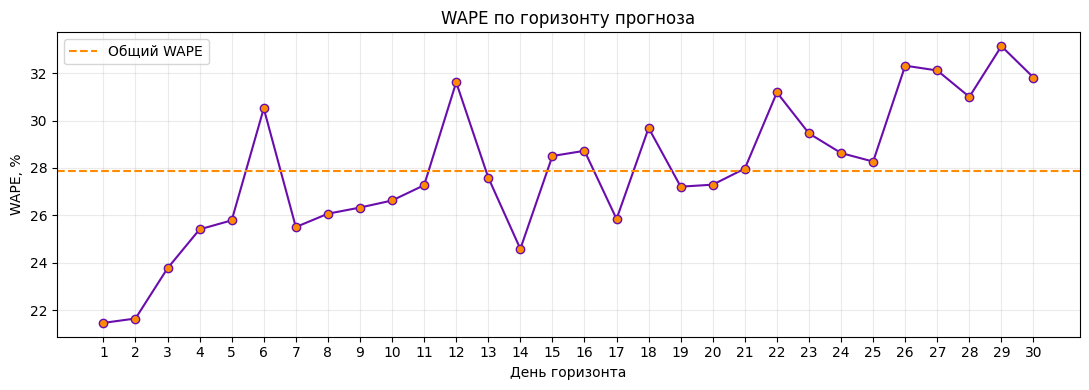

In [16]:
horizon_errors = final_test_forecast[['date', 'target_quantity', 'prediction']].copy()
horizon_errors['horizon'] = (horizon_errors['date'] - horizon_errors['date'].min()).dt.days + 1
horizon_errors['absolute_error'] = np.abs(horizon_errors['target_quantity'] - horizon_errors['prediction'])
horizon_errors['absolute_target'] = np.abs(horizon_errors['target_quantity'])

horizon_wape = horizon_errors.groupby('horizon', as_index=False)[['absolute_error', 'absolute_target']].sum()
horizon_wape['WAPE'] = horizon_wape['absolute_error'] / horizon_wape['absolute_target']

plt.figure(figsize=(11, 4))
plt.plot(horizon_wape['horizon'], horizon_wape['WAPE'] * 100, color=PURPLE, marker='o', markerfacecolor=ORANGE)
plt.axhline(final_test_wape * 100, color=ORANGE, linestyle='--', label='Общий WAPE')
plt.xticks(range(1, 31))
plt.xlabel('День горизонта')
plt.ylabel('WAPE, %')
plt.title('WAPE по горизонту прогноза')
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

### Вывод

К концу периода ошибка растёт. Ранние ошибки попадают в признаки следующих дней.

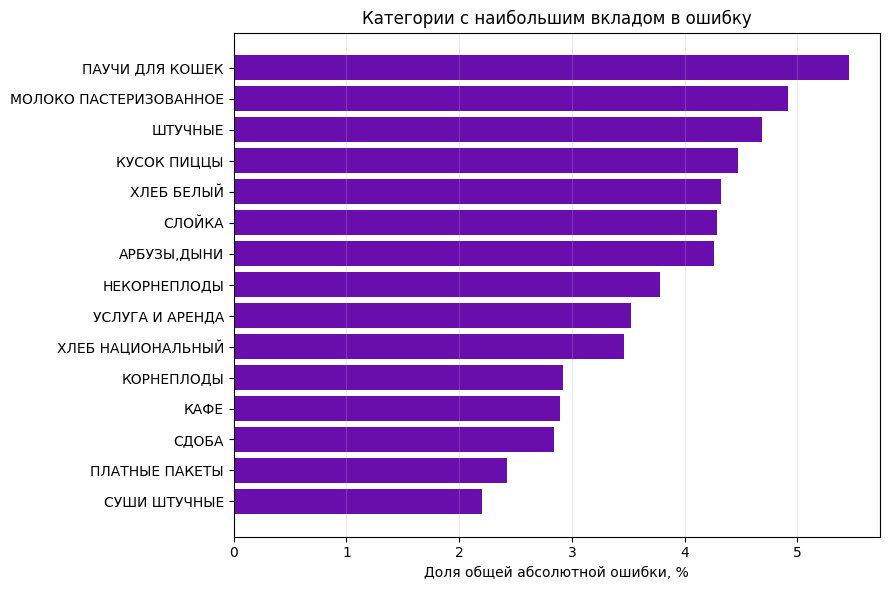

,class_name,actual_quantity,absolute_error,WAPE,error_share
0,ПАУЧИ ДЛЯ КОШЕК,9690.000,7120.465576,0.734826,0.054587
1,МОЛОКО ПАСТЕРИЗОВАННОЕ,15611.000,6417.380395,0.411081,0.049197
2,ШТУЧНЫЕ,35314.000,6106.618324,0.172923,0.046815
3,КУСОК ПИЦЦЫ,23782.000,5833.918885,0.245308,0.044724
4,ХЛЕБ БЕЛЫЙ,32717.000,5636.342529,0.172276,0.043210
5,СЛОЙКА,18015.000,5590.068398,0.310301,0.042855
6,"АРБУЗЫ,ДЫНИ",15914.872,5557.268210,0.349187,0.042603
7,НЕКОРНЕПЛОДЫ,11241.008,4930.915177,0.438654,0.037802
8,УСЛУГА И АРЕНДА,31480.000,4601.086540,0.146159,0.035273
9,ХЛЕБ НАЦИОНАЛЬНЫЙ,3368.000,4518.882819,1.341711,0.034643


In [17]:
error_data = final_test_forecast.copy()
error_data['absolute_error'] = np.abs(error_data['target_quantity'] - error_data['prediction'])
error_data['absolute_target'] = np.abs(error_data['target_quantity'])

category_errors = error_data.groupby('class_name', as_index=False).agg(actual_quantity=('absolute_target', 'sum'), absolute_error=('absolute_error', 'sum'))
category_errors['WAPE'] = category_errors['absolute_error'] / category_errors['actual_quantity']
category_errors['error_share'] = category_errors['absolute_error'] / category_errors['absolute_error'].sum()
category_errors = category_errors.sort_values('absolute_error', ascending=False).reset_index(drop=True)

top_categories = category_errors.head(15).sort_values('absolute_error')
plt.figure(figsize=(9, 6))
plt.barh(top_categories['class_name'], top_categories['error_share'] * 100, color=PURPLE)
plt.xlabel('Доля общей абсолютной ошибки, %')
plt.title('Категории с наибольшим вкладом в ошибку')
plt.grid(axis='x', alpha=0.25)
plt.tight_layout()
plt.show()

category_errors.head(15)

In [18]:
pair_errors = error_data.groupby(['item_id', 'store_id', 'class_name', 'item_type'], as_index=False).agg(actual_quantity=('absolute_target', 'sum'), predicted_quantity=('prediction', 'sum'), absolute_error=('absolute_error', 'sum'))
pair_errors['WAPE'] = np.where(pair_errors['actual_quantity'] > 0, pair_errors['absolute_error'] / pair_errors['actual_quantity'], np.nan)
pair_errors['error_share'] = pair_errors['absolute_error'] / pair_errors['absolute_error'].sum()
pair_errors = pair_errors.sort_values('absolute_error', ascending=False).reset_index(drop=True)

worst_pairs = pair_errors.head(20)
display(worst_pairs)

minimum_volume = pair_errors['actual_quantity'].median()
significant_pairs = pair_errors[pair_errors['actual_quantity'] >= minimum_volume]
display(significant_pairs.sort_values('WAPE', ascending=False).head(20))

,item_id,store_id,class_name,item_type,actual_quantity,predicted_quantity,absolute_error,WAPE,error_share
0,5b8e114fdf6f,1,"АРБУЗЫ,ДЫНИ","Арбузы, Дыни",14343.401,15718.826435,4513.410313,0.314668,0.034601
1,63161948a95a,1,УСЛУГА И АРЕНДА,UNKNOWN,23101.000,20118.230006,3135.806617,0.135743,0.024040
2,c90f3baff943,1,ХЛЕБ НАЦИОНАЛЬНЫЙ,Национальный,1.000,2464.850235,2463.850235,2463.850235,0.018889
3,2e58990eaa3c,1,КОРНЕПЛОДЫ,Картофель,9588.719,11101.338288,2154.202627,0.224660,0.016515
4,b0d24502fb66,1,ПЛАТНЫЕ ПАКЕТЫ,Упаковочный Материал,47976.000,47030.247867,2103.656679,0.043848,0.016127
5,4f2db5c52520,1,ВИНОГРАД,Виноград,2875.383,958.927159,1916.455841,0.666505,0.014692
6,e5b2b6f57ea7,1,КАФЕ,UNKNOWN,10003.000,8494.931125,1561.198320,0.156073,0.011969
7,cf8c74785482,1,НЕКОРНЕПЛОДЫ,Томаты,2556.131,1244.246633,1322.095775,0.517225,0.010136
8,9a7e315f3f42,1,ДОМАШНЯЯ КУХНЯ,UNKNOWN,9994.516,10599.445168,1313.090129,0.131381,0.010066
9,865a5f2dbf2e,1,МОЛОКО ПАСТЕРИЗОВАННОЕ,Пастеризованное,1600.000,875.979652,1049.381612,0.655864,0.008045


,item_id,store_id,class_name,item_type,actual_quantity,predicted_quantity,absolute_error,WAPE,error_share
53,3e8b6efb8917,1,ТВОРОГ,Творог,415.000,925.154942,510.154942,1.229289,0.003911
46,510eceff9df0,1,ПОНЧИКИ,Пончики,479.000,905.960827,541.158477,1.129767,0.004149
20,432c160c926d,1,КОСТОЧКОВЫЕ,Нектарины,776.654,1488.649752,813.186169,1.047038,0.006234
15,3dd3ee368a67,1,ЯЙЦО,Куриное,930.000,0.009544,930.009544,1.000010,0.007130
32,d6c21ae5f8a3,1,СОСИСКИ,Сосиски,672.000,8.252349,665.407789,0.990190,0.005101
95,448675bb116f,2,ПАУЧИ ДЛЯ КОШЕК,Паучи,366.000,59.916850,343.594553,0.938783,0.002634
77,7cec3a4eeb13,1,ПАУЧИ ДЛЯ КОШЕК,Паучи,427.000,67.934116,391.750108,0.917448,0.003003
92,2c7612527f51,1,ПАУЧИ ДЛЯ КОШЕК,Паучи,389.000,330.220599,351.311109,0.903113,0.002693
41,d156750230af,1,МОЛОКО ПАСТЕРИЗОВАННОЕ,Пастеризованное,641.000,1212.536339,571.536339,0.891632,0.004382
71,0d46d5000d19,1,СОСИСКИ,Сосиски,477.000,100.773084,417.136824,0.874501,0.003198


### Вывод

Большую часть ошибки дают несколько категорий и товарных пар.

Товар `c90f3baff943` в магазине 1 раньше продавался активно, но почти исчез в test. Модель не учла возможный вывод товара из ассортимента.

## 15. Важность признаков и SHAP

Важность признаков показывает общий вклад. SHAP помогает понять влияние признаков на отдельные прогнозы.

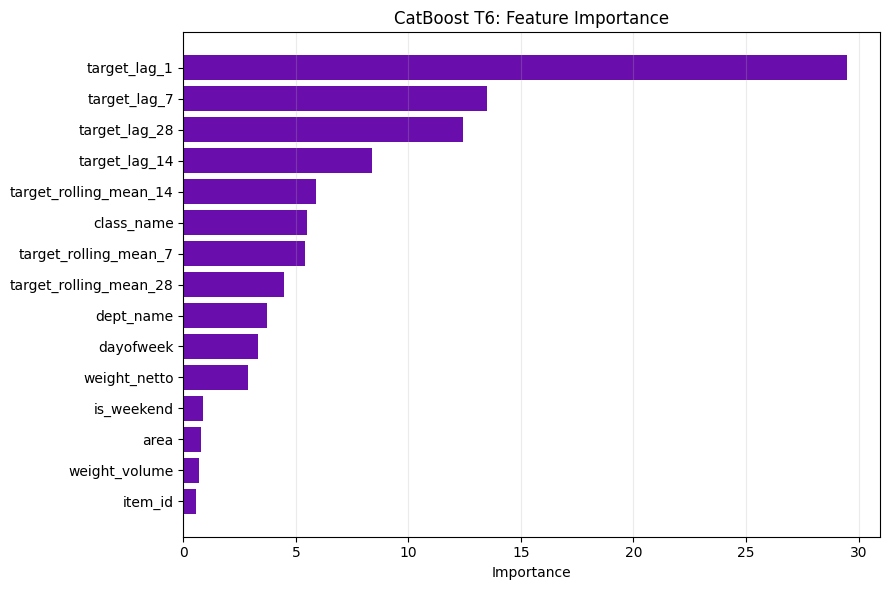

,feature,importance
0,target_lag_1,29.481305
1,target_lag_7,13.497406
2,target_lag_28,12.409634
3,target_lag_14,8.386568
4,target_rolling_mean_14,5.877959
5,class_name,5.469867
6,target_rolling_mean_7,5.400944
7,target_rolling_mean_28,4.480283
8,dept_name,3.695699
9,dayofweek,3.310687


In [19]:
feature_importance = pd.DataFrame({
    'feature': e3_features,
    'importance': final_model.get_feature_importance(),
}).sort_values('importance', ascending=False).reset_index(drop=True)

top_features = feature_importance.head(15).sort_values('importance')
plt.figure(figsize=(9, 6))
plt.barh(top_features['feature'], top_features['importance'], color=PURPLE)
plt.xlabel('Importance')
plt.title('CatBoost T6: Feature Importance')
plt.grid(axis='x', alpha=0.25)
plt.tight_layout()
plt.show()

feature_importance.head(15)

In [20]:
shap_sample = train_final.sample(n=min(5000, len(train_final)), random_state=42)
X_shap = shap_sample[e3_features]
shap_pool = Pool(X_shap, cat_features=cat_features)

shap_values = final_model.get_feature_importance(shap_pool, type='ShapValues')
shap_matrix = shap_values[:, :-1]
mean_abs_shap = pd.Series(np.abs(shap_matrix).mean(axis=0), index=e3_features).sort_values(ascending=False)

mean_abs_shap.head(15)

target_lag_1              10.075037
target_rolling_mean_7      6.197694
target_lag_28              3.032747
target_rolling_mean_28     2.748498
target_lag_7               2.504821
target_lag_14              2.306459
target_rolling_mean_14     1.865471
dayofweek                  1.328701
class_name                 1.074449
weight_netto               0.882759
item_id                    0.881208
dept_name                  0.847097
area                       0.828770
is_weekend                 0.750962
weight_volume              0.573398
dtype: float64

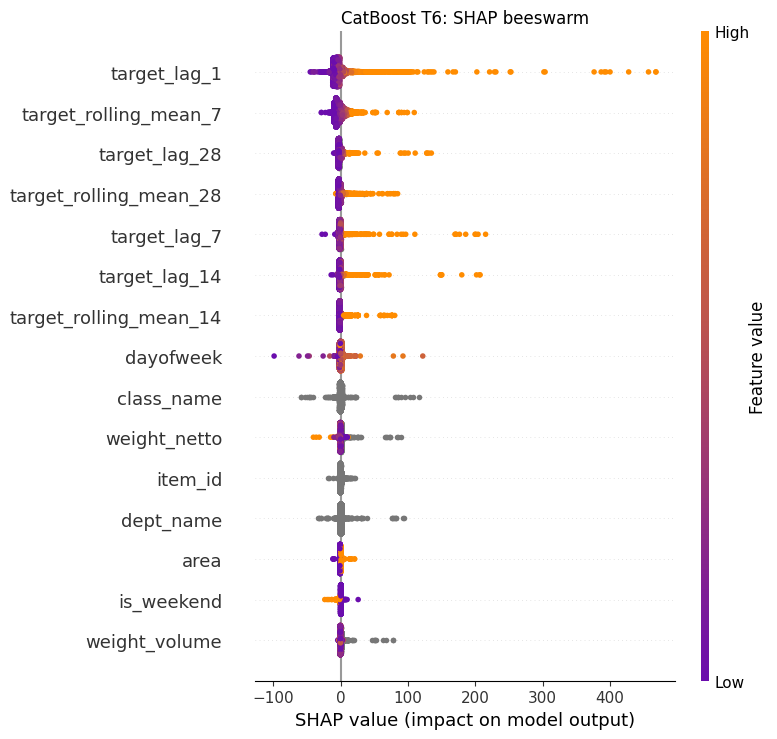

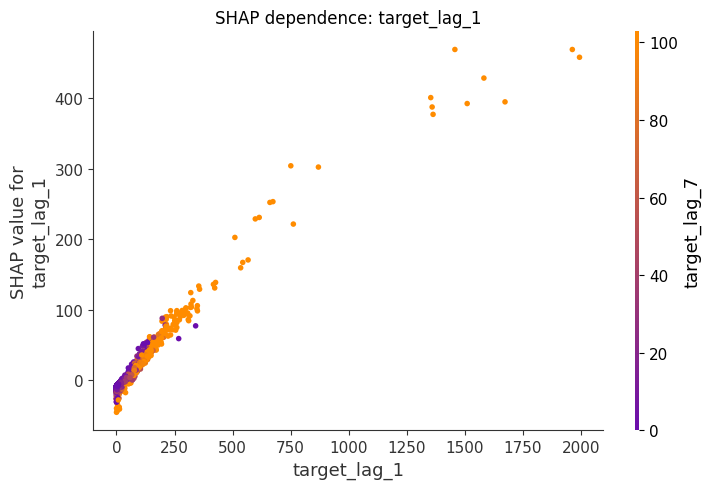

In [21]:
shap.summary_plot(shap_matrix, X_shap, feature_names=e3_features, max_display=15, cmap=PURPLE_ORANGE, show=False)
plt.title('CatBoost T6: SHAP beeswarm')
plt.tight_layout()
plt.show()

shap.dependence_plot('target_lag_1', shap_matrix, X_shap, interaction_index='target_lag_7', cmap=PURPLE_ORANGE, show=False)
plt.title('SHAP dependence: target_lag_1')
plt.tight_layout()
plt.show()

### Вывод

Главный сигнал — недавние продажи. Сильнее всего влияют лаги и скользящие средние.

## 16. Фактические значения и прогноз

Сравниваю удачный, средний и плохой прогноз на трёх товарах.

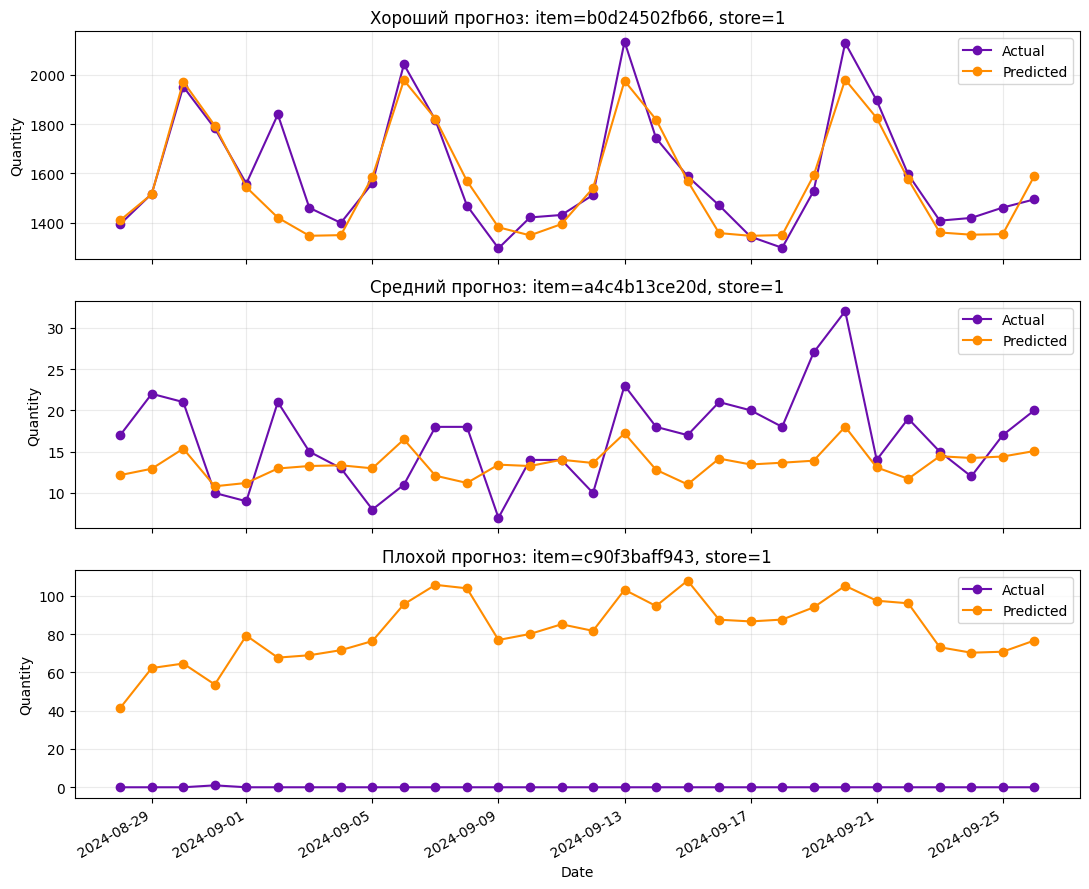

In [22]:
ranked_pairs = significant_pairs.sort_values('WAPE').reset_index(drop=True)
selected_pairs = pd.DataFrame([
    {'example': 'Хороший прогноз', 'item_id': ranked_pairs.iloc[0]['item_id'], 'store_id': ranked_pairs.iloc[0]['store_id']},
    {'example': 'Средний прогноз', 'item_id': ranked_pairs.iloc[len(ranked_pairs) // 2]['item_id'], 'store_id': ranked_pairs.iloc[len(ranked_pairs) // 2]['store_id']},
    {'example': 'Плохой прогноз', 'item_id': 'c90f3baff943', 'store_id': '1'},
])

fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)

for axis, pair in zip(axes, selected_pairs.itertuples(index=False)):
    series = final_test_forecast[(final_test_forecast['item_id'] == pair.item_id) & (final_test_forecast['store_id'] == pair.store_id)].sort_values('date')
    axis.plot(series['date'], series['target_quantity'], color=PURPLE, marker='o', label='Actual')
    axis.plot(series['date'], series['prediction'], color=ORANGE, marker='o', label='Predicted')
    axis.set_title(f'{pair.example}: item={pair.item_id}, store={pair.store_id}')
    axis.set_ylabel('Quantity')
    axis.grid(alpha=0.25)
    axis.legend()

axes[-1].set_xlabel('Date')
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

### Вывод

Модель передаёт общий уровень спроса, но сглаживает резкие изменения.

Она также продолжает прогнозировать спрос, если товар исчезает из ассортимента. В будущем можно добавить признак доступности товара.

## 17. Итоги

- построен прогноз на 30 дней;
- CatBoost сравнен с простым прогнозом и LightGBM;
- проверены группы признаков;
- подобраны параметры;
- выполнены анализ ошибок и SHAP.

**Результат на test:** MAE — 7.806, RMSE — 17.321, WAPE — 27.88%.

Главные ограничения: накопление ошибки, сглаживание скачков и изменение ассортимента.